In [1]:
# ==============================================================================
# 13. SHAP Analysis (모델 해석)
# ==============================================================================
#
# 목적:
#   1. SHAP을 통한 피처 중요도 분석
#   2. Global Feature Importance (전체 데이터)
#   3. Local Explanation (개별 예측)
#   4. FE 검증 (새로 만든 피처가 유용한지)
#
# SHAP (SHapley Additive exPlanations):
#   - 각 피처가 예측에 얼마나 기여했는지 정량화
#   - 게임 이론 기반 (Shapley Value)
#   - XGBoost/LightGBM에 최적화된 TreeExplainer 사용
# ==============================================================================

import pandas as pd
import numpy as np
import json
import os
import pickle
import shap
import matplotlib.pyplot as plt

INPUT_DIR = '../data/processed'
MODEL_DIR = '../models'
OUTPUT_DIR = '../reports'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=== 13. SHAP Analysis 시작 ===")

# --- 데이터 로드 ---
print("\nStep 1: 데이터 및 모델 로드")

df_test = pd.read_csv(os.path.join(INPUT_DIR, 'test.csv'))

with open(os.path.join(INPUT_DIR, 'feature_cols.json'), 'r') as f:
    feature_cols = json.load(f)

X_test = df_test[feature_cols]

print(f"✓ Test 데이터: {len(X_test):,} rows, {len(feature_cols)} features")

=== 13. SHAP Analysis 시작 ===

Step 1: 데이터 및 모델 로드
✓ Test 데이터: 142,801 rows, 66 features


In [2]:
# ==============================================================================
# Step 2: 모델 로드 및 타겟 선택
# ==============================================================================

print("\nStep 2: 모델 로드")

# 가장 최근 모델 찾기
model_files = [f for f in os.listdir(MODEL_DIR) if f.endswith('.pkl')]
print(f"  저장된 모델: {len(model_files)}개")

# 분석할 타겟 선택 (메인 타겟 하나 선택)
TARGET = 'death_next_24h'  # 변경 가능: vent_next_24h, pressor_next_24h, composite_next_24h
MODEL_TYPE = 'xgb'  # 변경 가능: 'lgb'

print(f"\n  분석 타겟: {TARGET}")
print(f"  모델 유형: {MODEL_TYPE}")

# 모델 파일 찾기
model_file = [f for f in model_files if f.startswith(f'{MODEL_TYPE}_{TARGET}')]
if model_file:
    model_file = sorted(model_file)[-1]  # 가장 최근
    model_path = os.path.join(MODEL_DIR, model_file)
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    print(f"✓ 모델 로드: {model_file}")
else:
    raise FileNotFoundError(f"모델 파일 없음: {MODEL_TYPE}_{TARGET}*.pkl")


Step 2: 모델 로드
  저장된 모델: 28개

  분석 타겟: death_next_24h
  모델 유형: xgb
✓ 모델 로드: xgb_death_next_24h_v2_lactate_special_20260108_004507.pkl


In [3]:
# ==============================================================================
# Step 3: SHAP Explainer 생성
# ==============================================================================
#
# TreeExplainer: XGBoost/LightGBM에 최적화
# - 빠른 계산 속도
# - 정확한 SHAP 값
# ==============================================================================

print("\nStep 3: SHAP Explainer 생성")

# TreeExplainer 생성
explainer = shap.TreeExplainer(model)

# SHAP 값 계산 (시간 걸릴 수 있음)
# 전체 데이터 대신 샘플 사용 (대용량 데이터 시)
SAMPLE_SIZE = min(10000, len(X_test))
X_sample = X_test.sample(n=SAMPLE_SIZE, random_state=42)

print(f"  SHAP 계산 중... (샘플: {SAMPLE_SIZE:,}개)")
shap_values = explainer.shap_values(X_sample)

# Binary classification의 경우 양성 클래스 SHAP만 사용
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # 양성 클래스

print(f"✓ SHAP 계산 완료")
print(f"  - SHAP values shape: {shap_values.shape}")


Step 3: SHAP Explainer 생성
  SHAP 계산 중... (샘플: 10,000개)
✓ SHAP 계산 완료
  - SHAP values shape: (10000, 66)


In [4]:
# ==============================================================================
# Step 4: Global Feature Importance
# ==============================================================================
#
# 전체 데이터에서 각 피처의 평균 |SHAP| 값
# = 해당 피처가 예측에 얼마나 기여하는지
# ==============================================================================

print("\nStep 4: Global Feature Importance")

# 피처별 평균 |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

# Top 20 출력
print("\n=== Top 20 Feature Importance ===")
for i, row in feature_importance.head(20).iterrows():
    print(f"  {feature_importance.index.get_loc(i)+1:2d}. {row['feature']}: {row['importance']:.4f}")

# 피처 그룹별 중요도 분석
print("\n=== 피처 그룹별 중요도 ===")

groups = {
    'Vital': ['hr', 'rr', 'spo2', 'temp', 'sbp', 'dbp', 'mbp'],
    'Lab': ['lactate', 'creatinine', 'wbc', 'platelets', 'potassium', 'sodium'],
    'GCS': ['gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total'],
    'Urine': ['urine_ml_6h', 'urine_ml_kg_hr_avg', 'oliguria_flag'],
    'Rolling': [c for c in feature_cols if '_6h' in c and 'urine' not in c],
    'Trend': [c for c in feature_cols if '_delta_' in c or '_slope_' in c],
    'Derived': ['shock_index', 'modified_shock_index', 'pulse_pressure'],
    'Scores': ['mews_score', 'news_score'],
    'Missing_Flags': ['lactate_missing', 'gcs_missing_flag', 'urine_missing_flag'],
    'Demographics': ['gender_male', 'anchor_age', 'hours_in_icu']
}

for group_name, group_features in groups.items():
    group_features_exist = [f for f in group_features if f in feature_cols]
    if group_features_exist:
        group_importance = feature_importance[feature_importance['feature'].isin(group_features_exist)]['importance'].sum()
        print(f"  {group_name}: {group_importance:.4f}")


Step 4: Global Feature Importance

=== Top 20 Feature Importance ===
   1. gcs_total: 0.4031
   2. news_score: 0.3322
   3. anchor_age: 0.2888
   4. creatinine: 0.2475
   5. gcs_motor: 0.2473
   6. rr_max_6h: 0.2244
   7. mews_score: 0.1790
   8. lactate: 0.1486
   9. spo2_min_6h: 0.1218
  10. modified_shock_index: 0.0925
  11. urine_ml_6h: 0.0908
  12. gcs_eye: 0.0879
  13. gcs_verbal: 0.0730
  14. shock_index: 0.0588
  15. potassium: 0.0502
  16. mbp_max_6h: 0.0498
  17. temp: 0.0416
  18. gcs_missing_flag: 0.0407
  19. hr_mean_6h: 0.0358
  20. wbc: 0.0290

=== 피처 그룹별 중요도 ===
  Vital: 0.0816
  Lab: 0.4980
  GCS: 0.8112
  Urine: 0.1086
  Rolling: 0.5918
  Trend: 0.0019
  Derived: 0.1553
  Scores: 0.5112
  Missing_Flags: 0.0576
  Demographics: 0.3026



Step 5: SHAP Summary Plot 생성


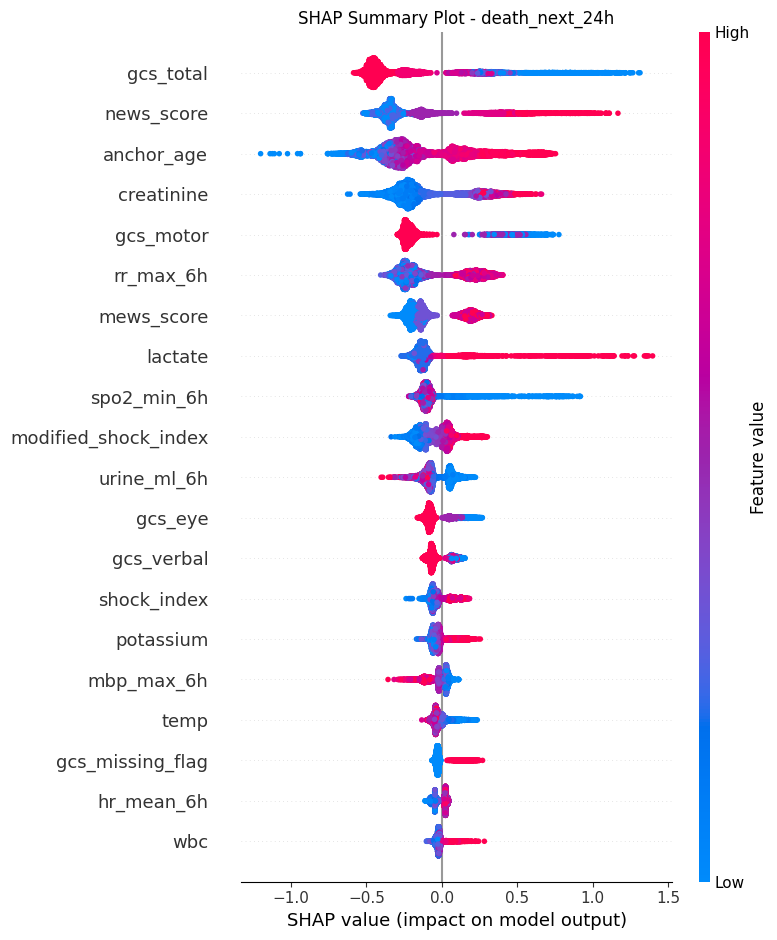

✓ 저장: ../reports/shap_summary_xgb_death_next_24h.png


In [5]:
# ==============================================================================
# Step 5: SHAP Summary Plot
# ==============================================================================
#
# Beeswarm plot: 각 데이터 포인트의 SHAP 값 분포
# - x축: SHAP 값 (양수=positive 예측 기여, 음수=negative 예측 기여)
# - 색상: 피처 값 (빨강=높음, 파랑=낮음)
# ==============================================================================

print("\nStep 5: SHAP Summary Plot 생성")

# Summary Plot (Top 20)
plt.figure(figsize=(10, 12))
shap.summary_plot(
    shap_values, 
    X_sample, 
    feature_names=feature_cols,
    max_display=20,
    show=False
)
plt.title(f'SHAP Summary Plot - {TARGET}')
plt.tight_layout()

summary_path = os.path.join(OUTPUT_DIR, f'shap_summary_{MODEL_TYPE}_{TARGET}.png')
plt.savefig(summary_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 저장: {summary_path}")


Step 6: SHAP Bar Plot 생성


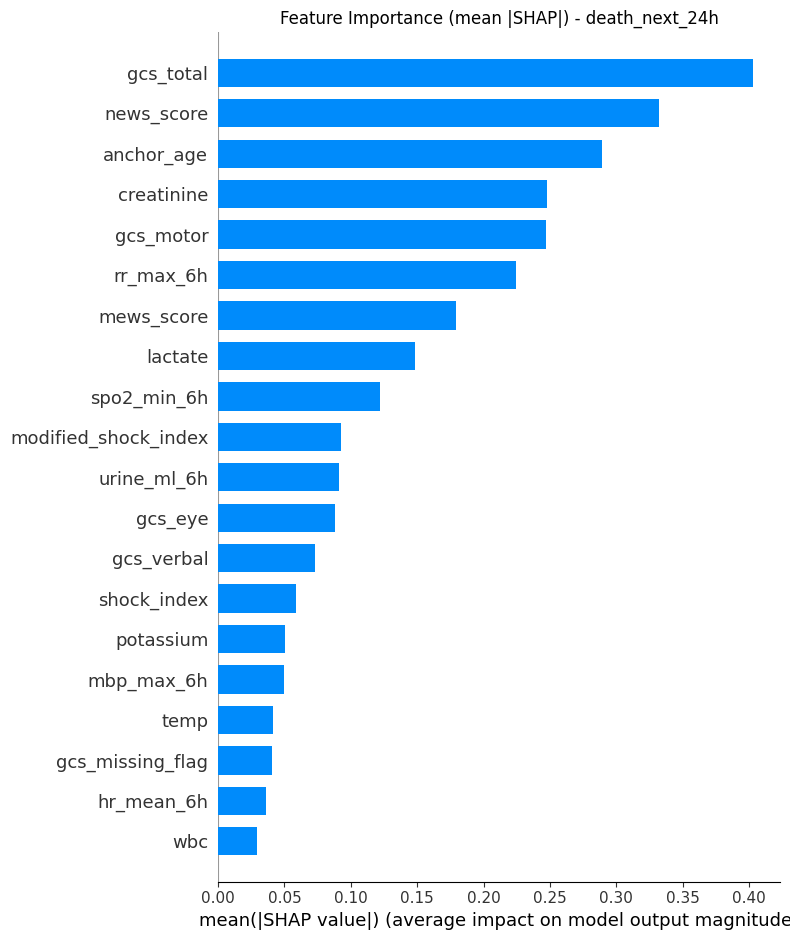

✓ 저장: ../reports/shap_bar_xgb_death_next_24h.png


In [6]:
# ==============================================================================
# Step 6: SHAP Bar Plot (Feature Importance)
# ==============================================================================

print("\nStep 6: SHAP Bar Plot 생성")

plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values, 
    X_sample, 
    feature_names=feature_cols,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title(f'Feature Importance (mean |SHAP|) - {TARGET}')
plt.tight_layout()

bar_path = os.path.join(OUTPUT_DIR, f'shap_bar_{MODEL_TYPE}_{TARGET}.png')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 저장: {bar_path}")

In [7]:
# ==============================================================================
# Step 7: Local Explanation (개별 예측 해석)
# ==============================================================================
#
# 특정 환자의 예측을 설명
# - 왜 이 환자가 고위험으로 분류되었는지
# - 어떤 피처가 예측에 기여했는지
# ==============================================================================

print("\nStep 7: Local Explanation (개별 예측)")

# 예측값 계산
y_pred = model.predict_proba(X_sample)[:, 1]

# 고위험 환자 선택 (예측 확률 상위)
high_risk_idx = np.argsort(y_pred)[-5:]  # 상위 5명

print("\n=== 고위험 환자 Top 5 ===")
for rank, idx in enumerate(reversed(high_risk_idx), 1):
    patient_prob = y_pred[idx]
    print(f"\n{rank}. 예측 확률: {patient_prob:.4f}")
    
    # 해당 환자의 SHAP 값
    patient_shap = shap_values[idx]
    patient_data = X_sample.iloc[idx]
    
    # Top 5 기여 피처
    top_features_idx = np.argsort(np.abs(patient_shap))[-5:][::-1]
    print(f"   Top 5 기여 피처:")
    for feat_idx in top_features_idx:
        feat_name = feature_cols[feat_idx]
        feat_value = patient_data.iloc[feat_idx]
        shap_value = patient_shap[feat_idx]
        direction = "↑" if shap_value > 0 else "↓"
        print(f"     - {feat_name}: {feat_value:.2f} (SHAP={shap_value:+.4f}) {direction}")


Step 7: Local Explanation (개별 예측)

=== 고위험 환자 Top 5 ===

1. 예측 확률: 0.9621
   Top 5 기여 피처:
     - lactate: 12.30 (SHAP=+0.5902) ↑
     - news_score: 6.00 (SHAP=+0.4704) ↑
     - gcs_total: 3.00 (SHAP=+0.4417) ↑
     - spo2_min_6h: 57.00 (SHAP=+0.4390) ↑
     - gcs_motor: 1.00 (SHAP=+0.3008) ↑

2. 예측 확률: 0.9621
   Top 5 기여 피처:
     - news_score: 7.00 (SHAP=+0.6728) ↑
     - lactate: 8.00 (SHAP=+0.6099) ↑
     - spo2_min_6h: 80.50 (SHAP=+0.5514) ↑
     - rr_max_6h: 34.33 (SHAP=+0.2090) ↑
     - mews_score: 6.00 (SHAP=+0.1994) ↑

3. 예측 확률: 0.9611
   Top 5 기여 피처:
     - lactate: 12.30 (SHAP=+0.5895) ↑
     - news_score: 6.00 (SHAP=+0.4704) ↑
     - gcs_total: 3.00 (SHAP=+0.4514) ↑
     - spo2_min_6h: 57.00 (SHAP=+0.4311) ↑
     - gcs_motor: 1.00 (SHAP=+0.3020) ↑

4. 예측 확률: 0.9545
   Top 5 기여 피처:
     - spo2_min_6h: 66.83 (SHAP=+0.6446) ↑
     - news_score: 6.00 (SHAP=+0.6337) ↑
     - gcs_total: 7.00 (SHAP=+0.3881) ↑
     - gcs_motor: 5.00 (SHAP=+0.3115) ↑
     - anchor_age: 91.00 (SHAP=+0


Step 8: Waterfall Plot 생성


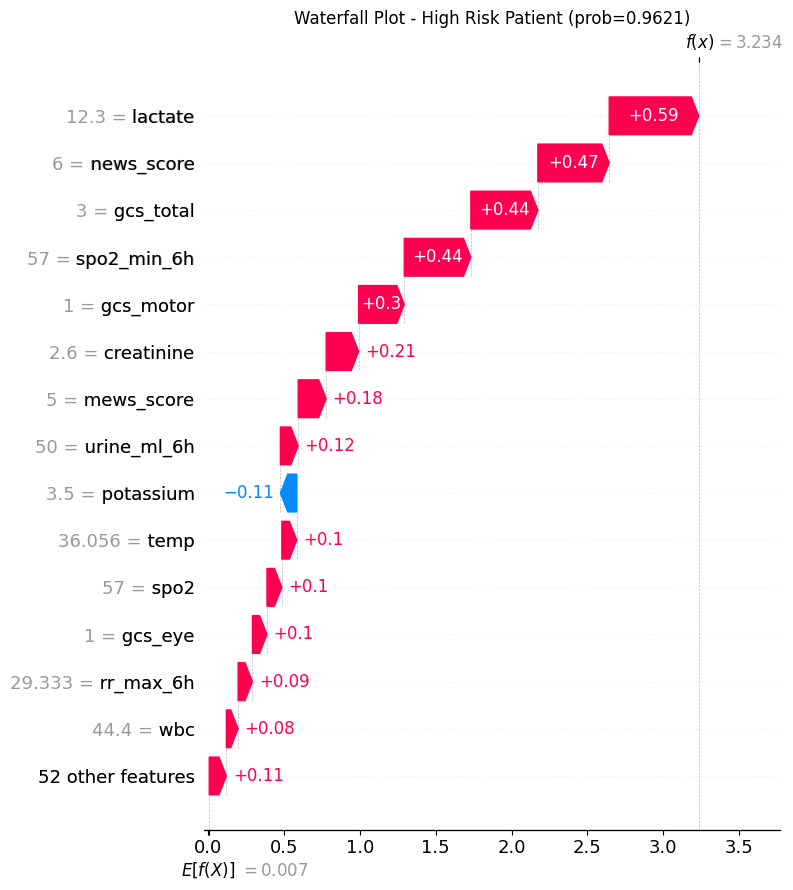

✓ 저장: ../reports/shap_waterfall_xgb_death_next_24h.png


In [8]:
# ==============================================================================
# Step 8: Waterfall Plot (단일 예측 상세)
# ==============================================================================
#
# 가장 고위험 환자 1명의 예측 분해
# - base value (평균 예측) → 최종 예측까지 각 피처 기여도
# ==============================================================================

print("\nStep 8: Waterfall Plot 생성")

# 가장 고위험 환자
high_risk_patient_idx = np.argmax(y_pred)

# base_value 처리
if isinstance(explainer.expected_value, np.ndarray):
    base_val = explainer.expected_value[1]  # binary classification
else:
    base_val = explainer.expected_value  # 이미 스칼라

plt.figure(figsize=(10, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_patient_idx],
        base_values=base_val,
        data=X_sample.iloc[high_risk_patient_idx],
        feature_names=feature_cols
    ),
    max_display=15,
    show=False
)
plt.title(f'Waterfall Plot - High Risk Patient (prob={y_pred[high_risk_patient_idx]:.4f})')
plt.tight_layout()

waterfall_path = os.path.join(OUTPUT_DIR, f'shap_waterfall_{MODEL_TYPE}_{TARGET}.png')
plt.savefig(waterfall_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 저장: {waterfall_path}")

In [9]:
# ==============================================================================
# Step 9: FE 검증 (새로 만든 피처가 유용한지)
# ==============================================================================
#
# 피처 엔지니어링에서 추가한 피처들의 순위 확인
# - Rolling, Trend, Derived, Scores 피처가 Top 20에 있으면 성공
# ==============================================================================

print("\nStep 9: FE 검증")

# FE에서 추가한 피처 카테고리
fe_categories = {
    'Rolling': [c for c in feature_cols if any(x in c for x in ['_mean_6h', '_std_6h', '_min_6h', '_max_6h'])],
    'Trend': [c for c in feature_cols if '_delta_' in c or '_slope_' in c],
    'Derived': ['shock_index', 'modified_shock_index', 'pulse_pressure'],
    'Scores': ['mews_score', 'news_score'],
}

print("\n=== FE 피처 순위 분석 ===")
for category, features in fe_categories.items():
    features_exist = [f for f in features if f in feature_cols]
    
    if features_exist:
        # 해당 카테고리 피처들의 순위
        category_ranks = []
        for feat in features_exist:
            rank = feature_importance[feature_importance['feature'] == feat].index
            if len(rank) > 0:
                rank_position = feature_importance.index.get_loc(rank[0]) + 1
                category_ranks.append((feat, rank_position))
        
        category_ranks.sort(key=lambda x: x[1])
        
        print(f"\n{category} ({len(features_exist)}개):")
        
        # Top 10 안에 있는 피처
        top10 = [f for f, r in category_ranks if r <= 10]
        top20 = [f for f, r in category_ranks if r <= 20]
        
        print(f"  - Top 10 진입: {len(top10)}개")
        print(f"  - Top 20 진입: {len(top20)}개")
        
        # 최상위 3개 출력
        for feat, rank in category_ranks[:3]:
            importance = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
            print(f"    #{rank}: {feat} ({importance:.4f})")


Step 9: FE 검증

=== FE 피처 순위 분석 ===

Rolling (20개):
  - Top 10 진입: 2개
  - Top 20 진입: 4개
    #6: rr_max_6h (0.2244)
    #9: spo2_min_6h (0.1218)
    #16: mbp_max_6h (0.0498)

Trend (15개):
  - Top 10 진입: 0개
  - Top 20 진입: 0개
    #47: hr_delta_3h (0.0008)
    #49: lactate_slope_3h (0.0007)
    #53: spo2_slope_3h (0.0003)

Derived (3개):
  - Top 10 진입: 1개
  - Top 20 진입: 2개
    #10: modified_shock_index (0.0925)
    #14: shock_index (0.0588)
    #38: pulse_pressure (0.0040)

Scores (2개):
  - Top 10 진입: 2개
  - Top 20 진입: 2개
    #2: news_score (0.3322)
    #7: mews_score (0.1790)


In [10]:
# ==============================================================================
# Step 10: 결과 저장
# ==============================================================================

print("\nStep 10: 결과 저장")

# Feature Importance 저장
importance_path = os.path.join(OUTPUT_DIR, f'feature_importance_{MODEL_TYPE}_{TARGET}.csv')
feature_importance.to_csv(importance_path, index=False)
print(f"✓ {importance_path}")

# SHAP 값 저장 (선택적, 대용량)
shap_df = pd.DataFrame(shap_values, columns=feature_cols)
shap_path = os.path.join(OUTPUT_DIR, f'shap_values_{MODEL_TYPE}_{TARGET}.csv')
shap_df.to_csv(shap_path, index=False)
print(f"✓ {shap_path}")

print("\n=== 15. SHAP Analysis 완료 ===")

# --- 최종 요약 ---
print("\n" + "="*60)
print("최종 요약")
print("="*60)

print(f"\n타겟: {TARGET}")
print(f"모델: {MODEL_TYPE.upper()}")

print(f"\nTop 5 Important Features:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {feature_importance.index.get_loc(i)+1}. {row['feature']}: {row['importance']:.4f}")

print(f"\n저장된 파일:")
print(f"  - {summary_path}")
print(f"  - {bar_path}")
print(f"  - {waterfall_path}")
print(f"  - {importance_path}")


Step 10: 결과 저장
✓ ../reports/feature_importance_xgb_death_next_24h.csv
✓ ../reports/shap_values_xgb_death_next_24h.csv

=== 15. SHAP Analysis 완료 ===

최종 요약

타겟: death_next_24h
모델: XGB

Top 5 Important Features:
  1. gcs_total: 0.4031
  2. news_score: 0.3322
  3. anchor_age: 0.2888
  4. creatinine: 0.2475
  5. gcs_motor: 0.2473

저장된 파일:
  - ../reports/shap_summary_xgb_death_next_24h.png
  - ../reports/shap_bar_xgb_death_next_24h.png
  - ../reports/shap_waterfall_xgb_death_next_24h.png
  - ../reports/feature_importance_xgb_death_next_24h.csv
